All Dependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.model_selection import train_test_split
from glob import glob

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Mount Drive (Execute only if using Colab)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

LR: (270, 64, 64, 1), HR: (270, 128, 128, 1), Channels: 1
Range — LR: [0.0141, 0.9744], HR: [0.0000, 1.0000]


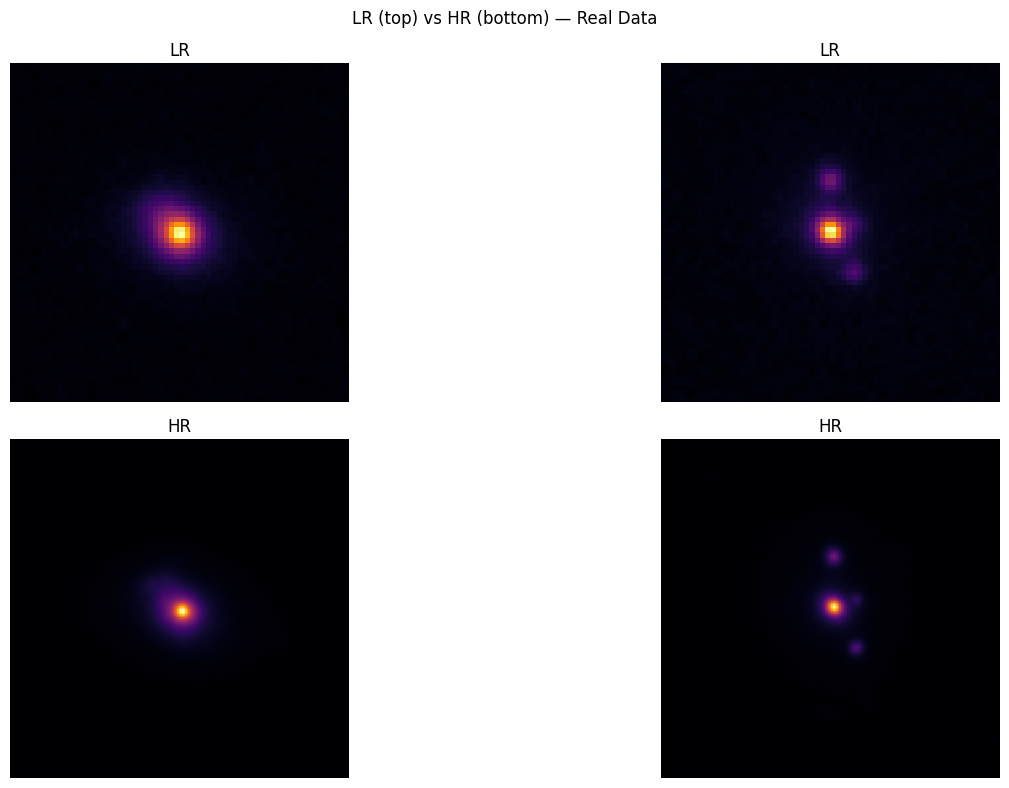

In [ ]:
file_path = "/content/drive/MyDrive/Tasks/SR_2/Dataset"

# Initialise parameters
LR_SIZE = 64
HR_SIZE = 128
SCALE = 2
BATCH_SIZE = 8
EPOCHS = 200
LEARNING_RATE = 5e-5
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def load_dataset(dataset_dir):
  lr_dict = {}
  hr_dict = {}
  LR = []
  HR = []

  for d in os.listdir(dataset_dir):
    if d == "LR":
      lr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(lr_dir):
        if img.endswith(".npy"):
          img_data = np.load(os.path.join(lr_dir, img))
          img_data = np.transpose(img_data, (1, 2, 0))
          idx = img[3:]
          lr_dict[idx] = img_data
    if d == "HR":
      hr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(hr_dir):
        if img.endswith(".npy"):
          img_data = np.load(os.path.join(hr_dir, img))
          img_data = np.transpose(img_data, (1, 2, 0))
          idx = img[3:]
          hr_dict[idx] = img_data

  for fname in lr_dict:
    if fname in hr_dict:
      LR.append(lr_dict[fname])
      HR.append(hr_dict[fname])

  LR = np.array(LR, dtype=np.float32)
  HR = np.array(HR, dtype=np.float32)

  # Normalize to [0, 1] globally
  global_min = min(LR.min(), HR.min())
  global_max = max(LR.max(), HR.max())
  LR = (LR - global_min) / (global_max - global_min + 1e-8)
  HR = (HR - global_min) / (global_max - global_min + 1e-8)

  #90-10 split
  hr_train,hr_test,lr_train,lr_test = train_test_split(HR,LR,test_size=0.10,random_state=SEED)
  return hr_train,hr_test,lr_train,lr_test

hr_train, hr_test, lr_train, lr_test = load_dataset(file_path)

NUM_CHANNELS = lr_train.shape[-1]
print(f"LR: {lr_train.shape}, HR: {hr_train.shape}, Channels: {NUM_CHANNELS}")
print(f"Range — LR: [{lr_train.min():.4f}, {lr_train.max():.4f}], HR: [{hr_train.min():.4f}, {hr_train.max():.4f}]")

fig,axes=plt.subplots(2,2,figsize=(16,8))
for i in range(2):
    axes[0,i].imshow(lr_test[i,:,:,0], cmap='inferno'); axes[0,i].set_title("LR")
    axes[0,i].axis('off')
    axes[1,i].imshow(hr_test[i,:,:,0], cmap='inferno'); axes[1,i].set_title("HR")
    axes[1,i].axis('off')
plt.suptitle("LR (top) vs HR (bottom) — Real Data")
plt.tight_layout()
plt.show()

Build Model

In [13]:
### AUGMENTED DATA
def augment_pair(hr, lr):
    if np.random.random() > 0.5: hr = np.flip(hr, 1); lr = np.flip(lr, 1)
    if np.random.random() > 0.5: hr = np.flip(hr, 0); lr = np.flip(lr, 0)
    k = np.random.randint(4)
    hr = np.rot90(hr, k); lr = np.rot90(lr, k)
    f = np.random.uniform(0.9, 1.1)
    hr = np.clip(hr * f, 0, 1); lr = np.clip(lr * f, 0, 1)
    return hr.copy(), lr.copy()

def aug_generator(hr, lr, bs):
    n = len(hr)
    while True:
        idx = np.random.randint(0, n, bs)
        hb, lb = [], []
        for i in idx:
            h, l = augment_pair(hr[i], lr[i])
            hb.append(h); lb.append(l)
        yield np.array(lb, np.float32), np.array(hb, np.float32)

### BUILD GENERATOR — 64×64 → 128×128
def res_block(x, f=64):
    s = x
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    return layers.Add()([x, s])

inp = keras.Input(shape=(LR_SIZE, LR_SIZE, NUM_CHANNELS))
x = layers.Conv2D(64, 9, padding='same')(inp)
x = layers.PReLU(shared_axes=[1,2])(x)
skip = x

for _ in range(16):
    x = res_block(x, 64)

x = layers.Conv2D(64, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Add()([x, skip])

x = layers.Conv2D(256, 3, padding='same')(x)
x = layers.Lambda(lambda t: tf.nn.depth_to_space(t, 2))(x)
x = layers.PReLU(shared_axes=[1,2])(x)

out = layers.Conv2D(NUM_CHANNELS, 9, padding='same', activation='sigmoid')(x)

generator = keras.Model(inp, out, name="Generator_64to128")
generator.summary()

### Transfer Learning from simulated generator (SR_1)
p_inp = keras.Input(shape=(75, 75, 1))
px = layers.Conv2D(64, 9, padding='same')(p_inp)
px = layers.PReLU(shared_axes=[1,2])(px)
p_skip = px
for _ in range(16):
    p_s = px
    px = layers.Conv2D(64, 3, padding='same')(px)
    px = layers.BatchNormalization()(px)
    px = layers.PReLU(shared_axes=[1,2])(px)
    px = layers.Conv2D(64, 3, padding='same')(px)
    px = layers.BatchNormalization()(px)
    px = layers.Add()([px, p_s])
px = layers.Conv2D(64, 3, padding='same')(px)
px = layers.BatchNormalization()(px)
px = layers.Add()([px, p_skip])
px = layers.Conv2D(256, 3, padding='same')(px)
px = layers.Lambda(lambda t: tf.nn.depth_to_space(t, 2),
                   output_shape=(150, 150, 64))(px)
px = layers.PReLU(shared_axes=[1,2])(px)
p_out = layers.Conv2D(1, 9, padding='same', activation='sigmoid')(px)
pretrained = keras.Model(p_inp, p_out)

keras.config.enable_unsafe_deserialization()
pretrained.load_weights("/content/drive/MyDrive/Tasks/generator_simulated_final.keras")

transferred = 0
for new_layer, pre_layer in zip(generator.layers, pretrained.layers):
    weights = pre_layer.get_weights()
    if len(weights) > 0 and new_layer.get_weights()[0].shape == weights[0].shape:
        new_layer.set_weights(weights)
        transferred += 1

print(f"Transferred weights from {transferred} layers (simulated -> real)")

Model: "Generator_64to128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 64, 64,    │      5,248 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_54 (PReLU)  │ (None, 64, 64,    │         64 │ conv2d_108[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 64, 64,    │     36,928 │ p_re_lu_54[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_109[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_55 (PReLU)  │ (None, 64, 64,    │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 64, 64,    │     36,928 │ p_re_lu_55[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_110[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_51 (Add)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ p_re_lu_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 64, 64,    │     36,928 │ add_51[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_111[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_56 (PReLU)  │ (None, 64, 64,    │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 64, 64,    │     36,928 │ p_re_lu_56[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_112[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_52 (Add)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ add_51[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 64, 64,    │     36,928 │ add_52[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_113[0][0]

 Total params: 1,386,369 (5.29 MB)

 Trainable params: 1,382,145 (5.27 MB)

 Non-trainable params: 4,224 (16.50 KB)

Transferred weights from 87 layers (simulated -> real)


Train Model

In [14]:
def compute_metrics(hr, sr):
    mse = np.mean((hr - sr)**2, axis=(1,2,3))
    psnr = 10 * np.log10(1.0 / (mse + 1e-10))
    ssim = tf.image.ssim(hr, sr, max_val=1.0).numpy()
    return np.mean(mse), np.mean(psnr), np.mean(ssim)

sr_base = generator.predict(lr_test, verbose=0)
m0, p0, s0 = compute_metrics(hr_test, sr_base)
print(f"Before fine-tuning — MSE: {m0:.6f} | PSNR: {p0:.2f} dB | SSIM: {s0:.4f}")

opt = optimizers.Adam(LEARNING_RATE)
mae_fn = keras.losses.MeanAbsoluteError()

@tf.function
def train_step(lr_b, hr_b):
    with tf.GradientTape() as t:
        sr = generator(lr_b, training=True)
        loss = mae_fn(hr_b, sr)
    opt.apply_gradients(zip(t.gradient(loss, generator.trainable_variables),
                             generator.trainable_variables))
    return loss

steps_per_epoch = max(len(lr_train) // BATCH_SIZE, 1) * 4
gen = aug_generator(hr_train, lr_train, BATCH_SIZE)
hist = {'loss':[], 'psnr':[], 'ssim':[]}
best_ssim = s0

for ep in range(EPOCHS):
    el = 0
    for _ in range(steps_per_epoch):
        lb, hb = next(gen)
        el += train_step(lb, hb).numpy()
    el /= steps_per_epoch

    sr_v = generator.predict(lr_test, verbose=0)
    _, pv, sv = compute_metrics(hr_test, sr_v)
    hist['loss'].append(el); hist['psnr'].append(pv); hist['ssim'].append(sv)

    if sv > best_ssim:
        best_ssim = sv
        generator.save_weights("best_generator_real.weights.h5")

    if (ep+1) % 20 == 0 or ep == 0:
        print(f"Ep {ep+1:3d}/{EPOCHS} | Loss: {el:.5f} | PSNR: {pv:.2f} | SSIM: {sv:.4f}")

Before fine-tuning — MSE: 0.008657 | PSNR: 23.72 dB | SSIM: 0.7435
Ep   1/200 | Loss: 0.02189 | PSNR: 34.30 | SSIM: 0.9281
Ep  20/200 | Loss: 0.01372 | PSNR: 36.29 | SSIM: 0.9414
Ep  40/200 | Loss: 0.01434 | PSNR: 34.66 | SSIM: 0.9444
Ep  60/200 | Loss: 0.01385 | PSNR: 35.91 | SSIM: 0.9465
Ep  80/200 | Loss: 0.01363 | PSNR: 36.43 | SSIM: 0.9475
Ep 100/200 | Loss: 0.01355 | PSNR: 36.08 | SSIM: 0.9463
Ep 120/200 | Loss: 0.01403 | PSNR: 34.87 | SSIM: 0.9391
Ep 140/200 | Loss: 0.01315 | PSNR: 34.95 | SSIM: 0.9446
Ep 160/200 | Loss: 0.01334 | PSNR: 35.97 | SSIM: 0.9462
Ep 180/200 | Loss: 0.01275 | PSNR: 36.33 | SSIM: 0.9487
Ep 200/200 | Loss: 0.01395 | PSNR: 36.10 | SSIM: 0.9468


Plot Model

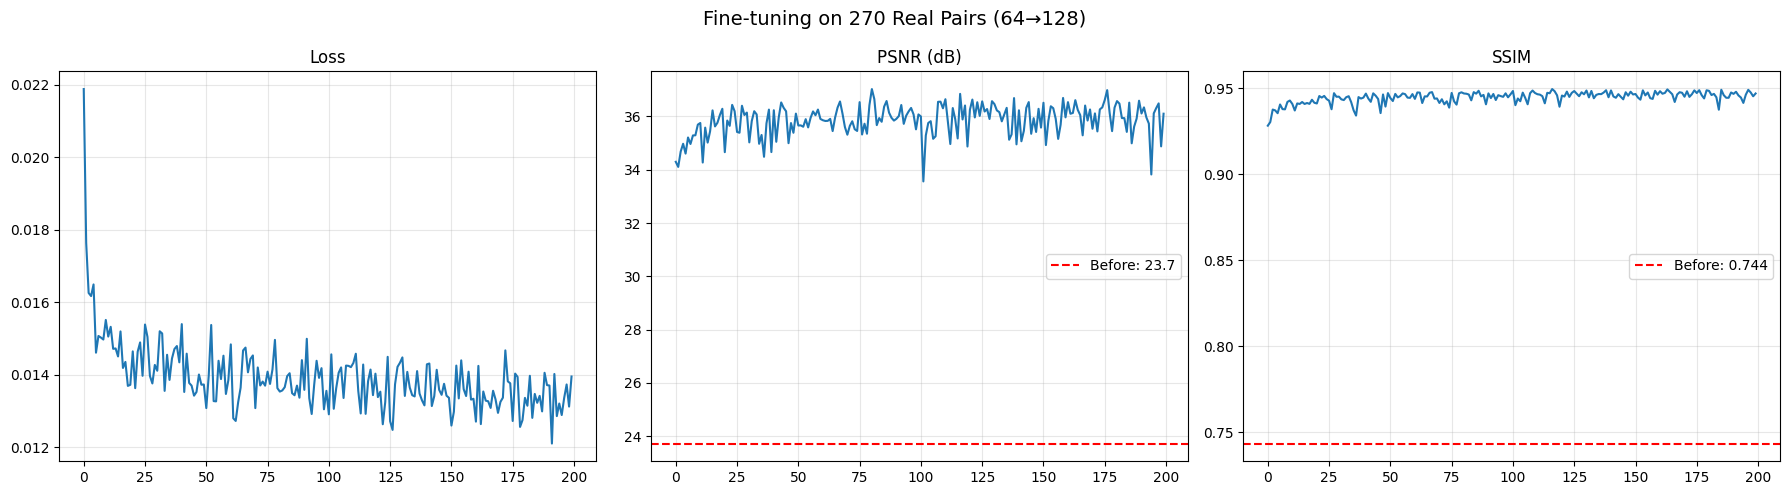

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(hist['loss']); ax[0].set_title('Loss'); ax[0].grid(alpha=0.3)
ax[1].plot(hist['psnr']); ax[1].axhline(p0, color='r', ls='--', label=f'Before: {p0:.1f}')
ax[1].set_title('PSNR (dB)'); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[2].plot(hist['ssim']); ax[2].axhline(s0, color='r', ls='--', label=f'Before: {s0:.3f}')
ax[2].set_title('SSIM'); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.suptitle("Fine-tuning on 270 Real Pairs (64→128)", fontsize=14)
plt.tight_layout(); plt.savefig("curves_VIB.png", dpi=150); plt.show()

Test Model

FINAL METRICS — Real Telescope Data (64→128)
  Method                           MSE  PSNR (dB)       SSIM
  Bicubic interpolation       0.006901      24.72     0.6933
  Before fine-tuning          0.008657      23.72     0.7435
  After fine-tuning           0.000379      36.85     0.9494

  Improvement over bicubic:    PSNR +12.13 dB | SSIM +0.2561
  Improvement from fine-tune:  PSNR +13.12 dB | SSIM +0.2059


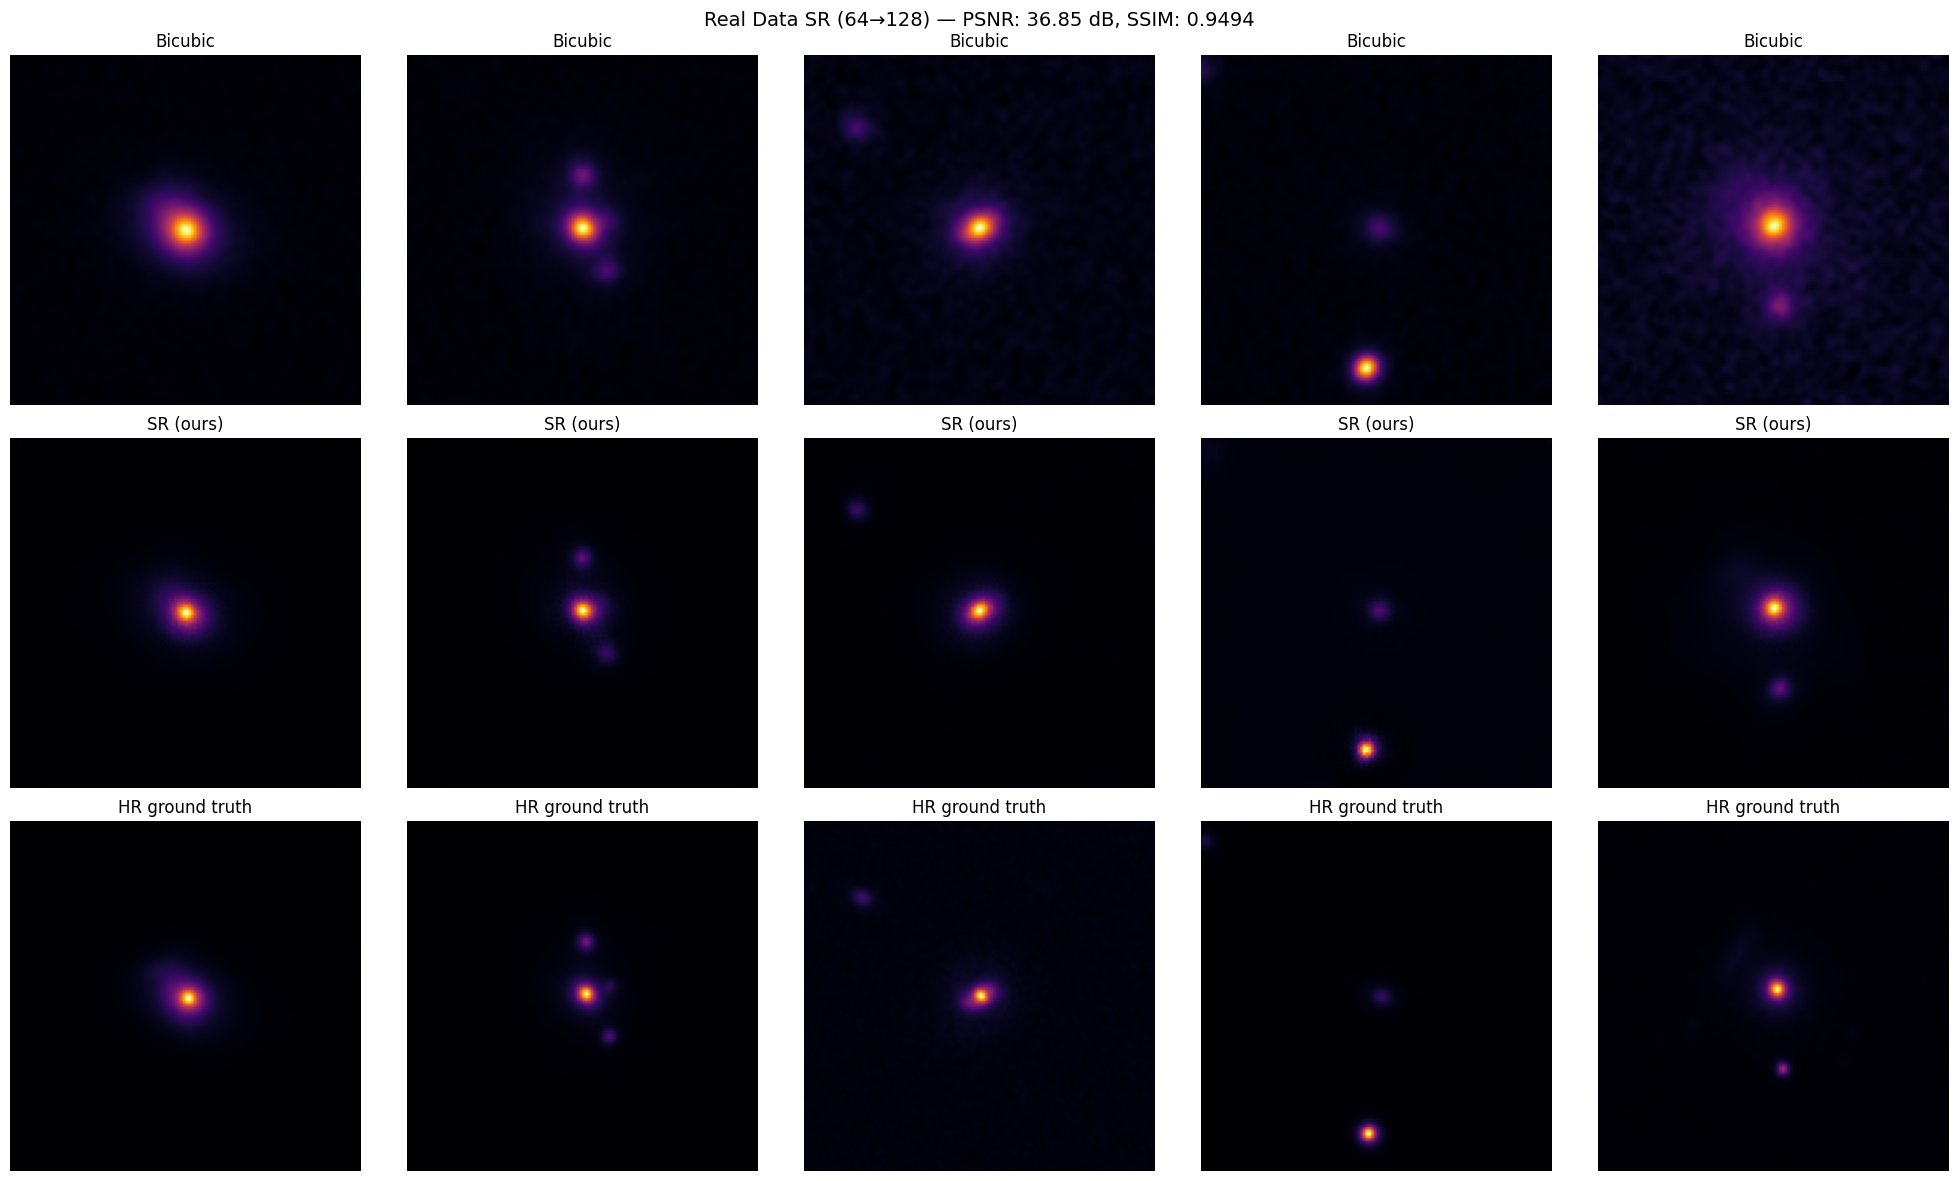

In [16]:
generator.load_weights("best_generator_real.weights.h5")
sr_test = generator.predict(lr_test, verbose=0)
mf, pf, sf = compute_metrics(hr_test, sr_test)

bic = np.clip(tf.image.resize(lr_test, [HR_SIZE, HR_SIZE], method='bicubic').numpy(), 0, 1)
mb, pb, sb = compute_metrics(hr_test, bic)

print("=" * 60)
print("FINAL METRICS — Real Telescope Data (64→128)")
print("=" * 60)
print(f"  {'Method':<25s} {'MSE':>10s} {'PSNR (dB)':>10s} {'SSIM':>10s}")
print(f"  {'Bicubic interpolation':<25s} {mb:>10.6f} {pb:>10.2f} {sb:>10.4f}")
print(f"  {'Before fine-tuning':<25s} {m0:>10.6f} {p0:>10.2f} {s0:>10.4f}")
print(f"  {'After fine-tuning':<25s} {mf:>10.6f} {pf:>10.2f} {sf:>10.4f}")
print()
print(f"  Improvement over bicubic:    PSNR +{pf-pb:.2f} dB | SSIM +{sf-sb:.4f}")
print(f"  Improvement from fine-tune:  PSNR +{pf-p0:.2f} dB | SSIM +{sf-s0:.4f}")

n = min(5, len(lr_test))
fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
for i in range(n):
    lr_up = tf.image.resize(lr_test[i:i+1], [HR_SIZE, HR_SIZE]).numpy()[0]
    axes[0,i].imshow(np.clip(lr_up[:,:,0],0,1), cmap='inferno'); axes[0,i].set_title("Bicubic"); axes[0,i].axis('off')
    axes[1,i].imshow(np.clip(sr_test[i,:,:,0],0,1), cmap='inferno'); axes[1,i].set_title("SR (ours)"); axes[1,i].axis('off')
    axes[2,i].imshow(hr_test[i,:,:,0], cmap='inferno'); axes[2,i].set_title("HR ground truth"); axes[2,i].axis('off')
plt.suptitle(f"Real Data SR (64→128) — PSNR: {pf:.2f} dB, SSIM: {sf:.4f}", fontsize=14)
plt.tight_layout(); plt.savefig("sr_results_real.png", dpi=150); plt.show()